In [1]:
from pathlib import Path
from ecg_analyzer.io import load_ecg_file
from ecg_analyzer.preprocess import remove_baseline_wander, general_waveform_bandpass, qrs_detection_bandpass
from ecg_analyzer.utils import plot_ecg

In [2]:
test_path = Path.cwd()

# Test 100

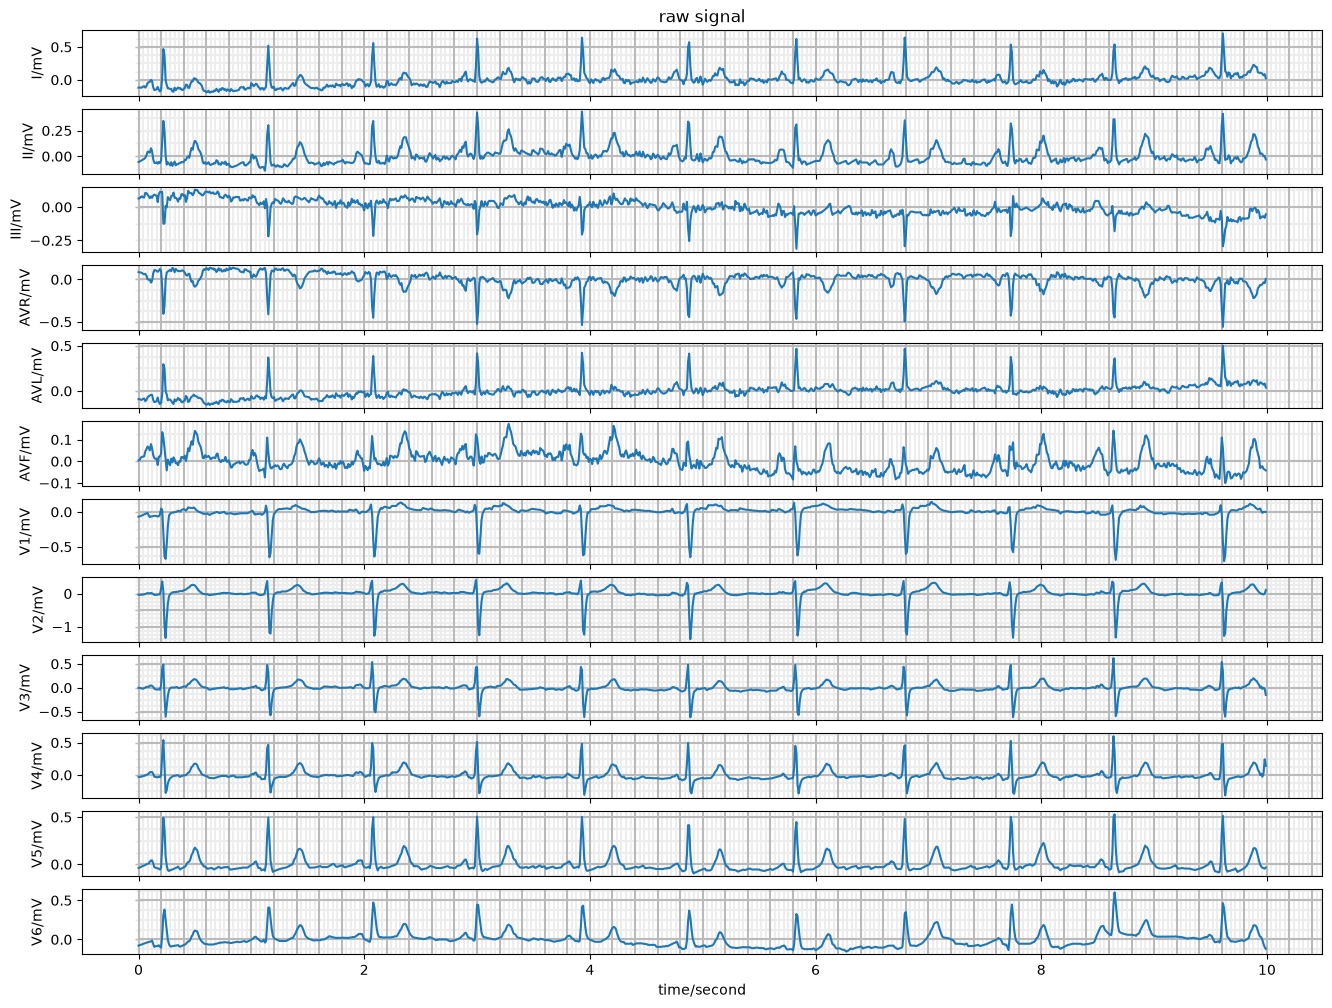

In [3]:
rec = load_ecg_file(test_path, "00001_lr", "100")
plot_ecg(rec, title="raw signal")

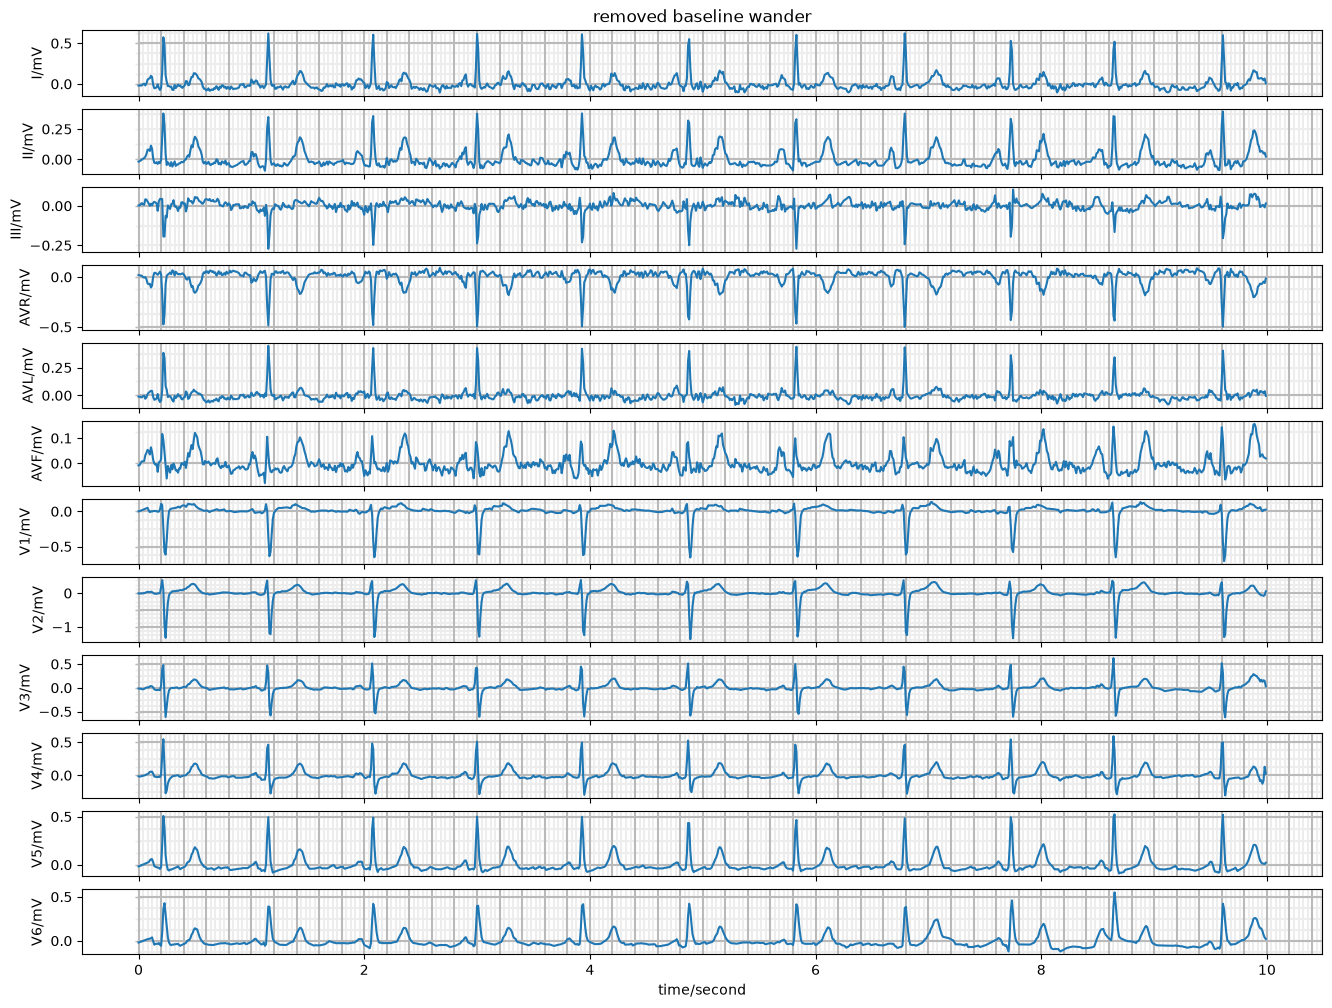

In [4]:
filtered_leads = remove_baseline_wander(rec.leads, rec.sample_rate)
rec = rec.model_copy(update={"leads": filtered_leads})
plot_ecg(rec, title="removed baseline wander")

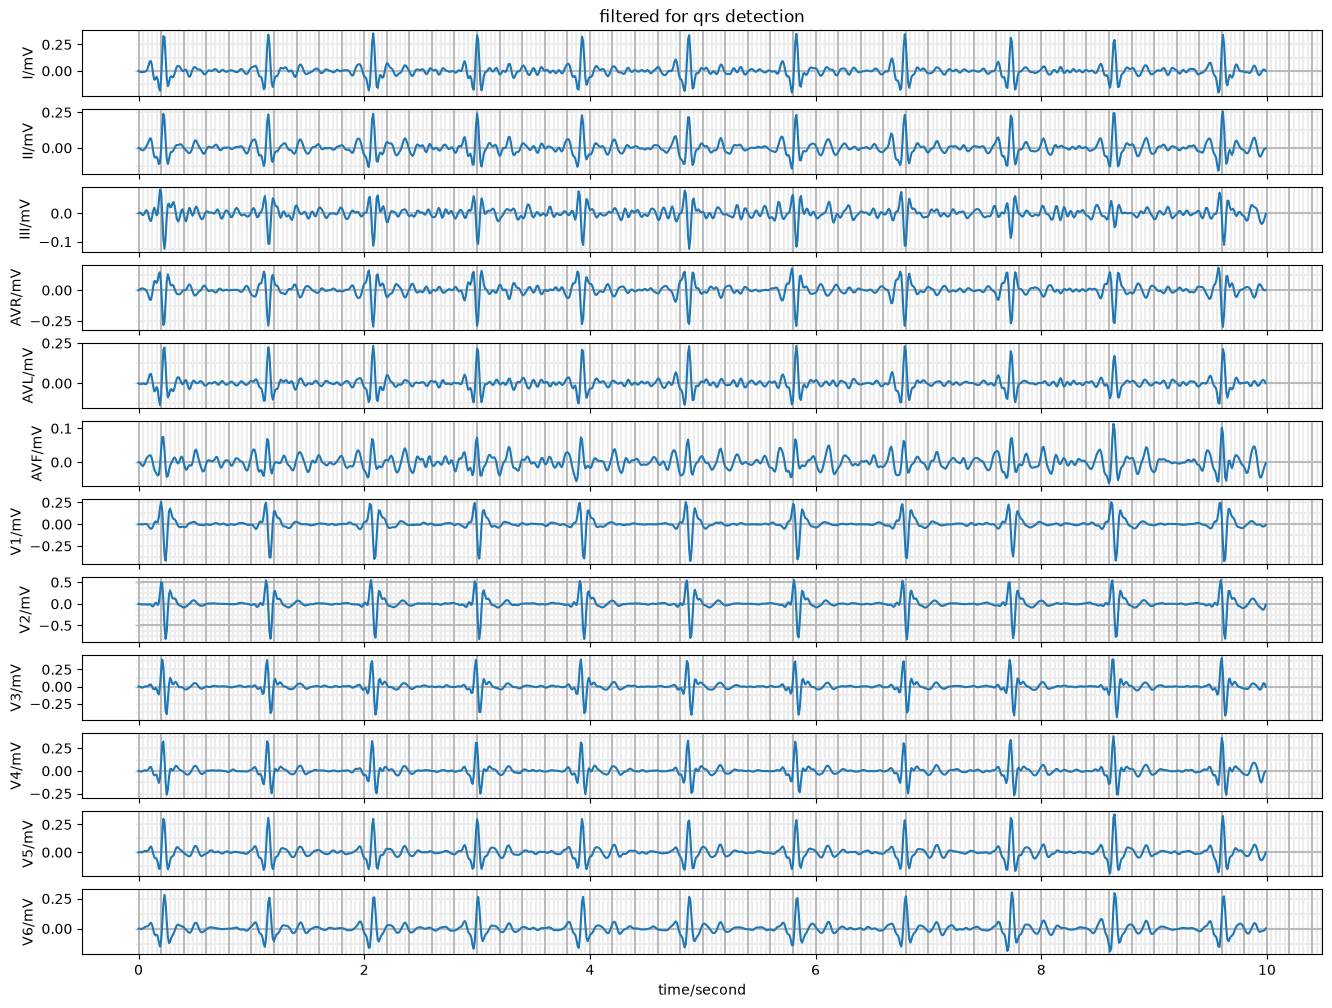

In [5]:
filtered_leads = qrs_detection_bandpass(rec.leads, rec.sample_rate)
rec = rec.model_copy(update={"leads": filtered_leads})
plot_ecg(rec, title="filtered for qrs detection")

# Test 500

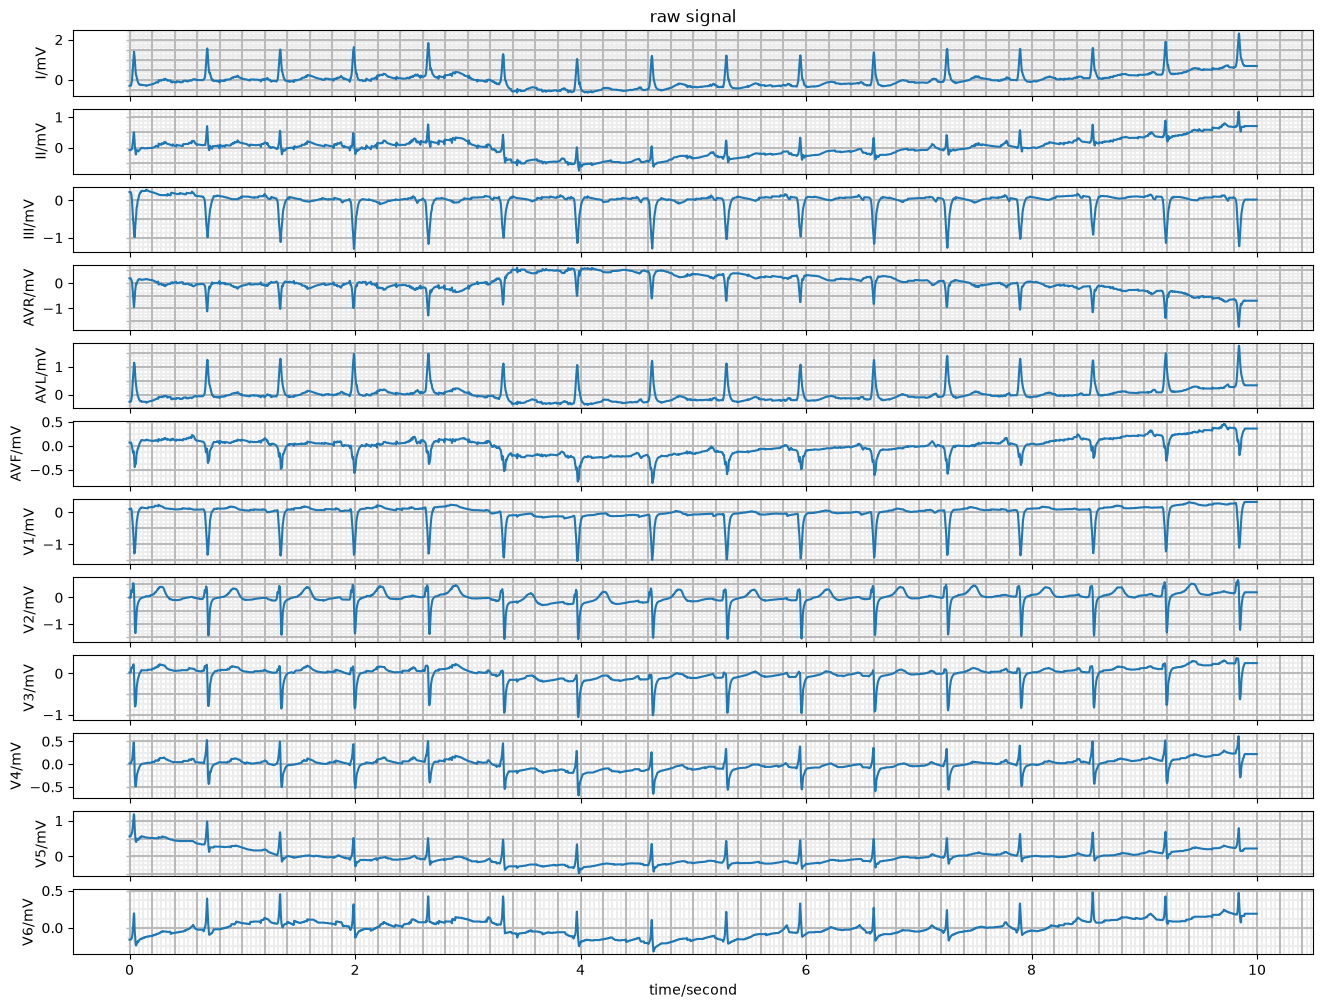

In [6]:
rec = load_ecg_file(test_path, "04048_hr", "500")
plot_ecg(rec, title="raw signal")

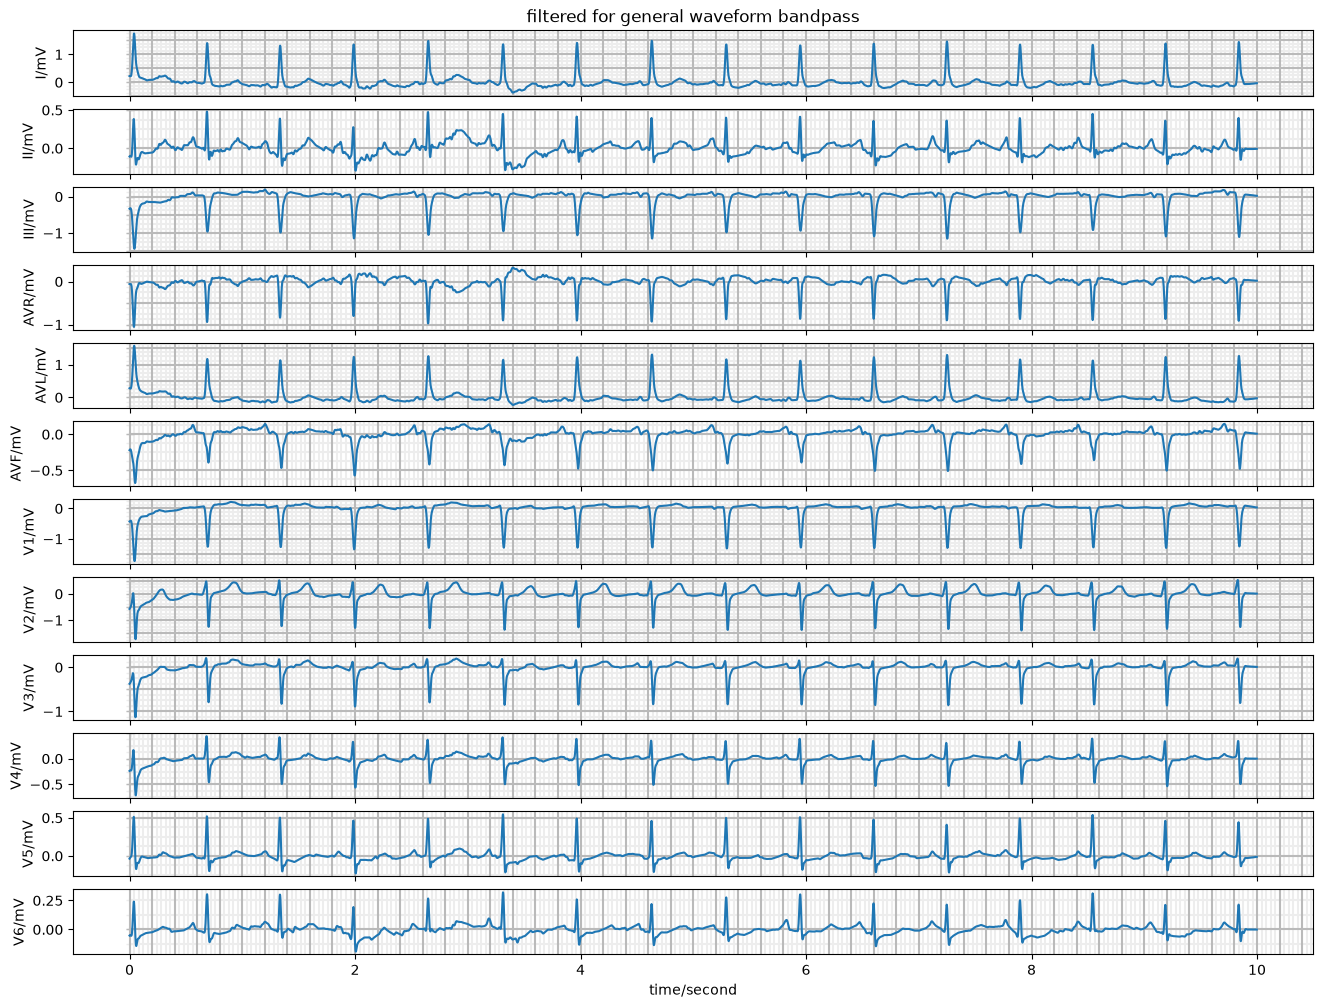

In [7]:
filtered_leads = general_waveform_bandpass(rec.leads, rec.sample_rate)
rec = rec.model_copy(update={"leads": filtered_leads})
plot_ecg(rec, title="filtered for general waveform bandpass")

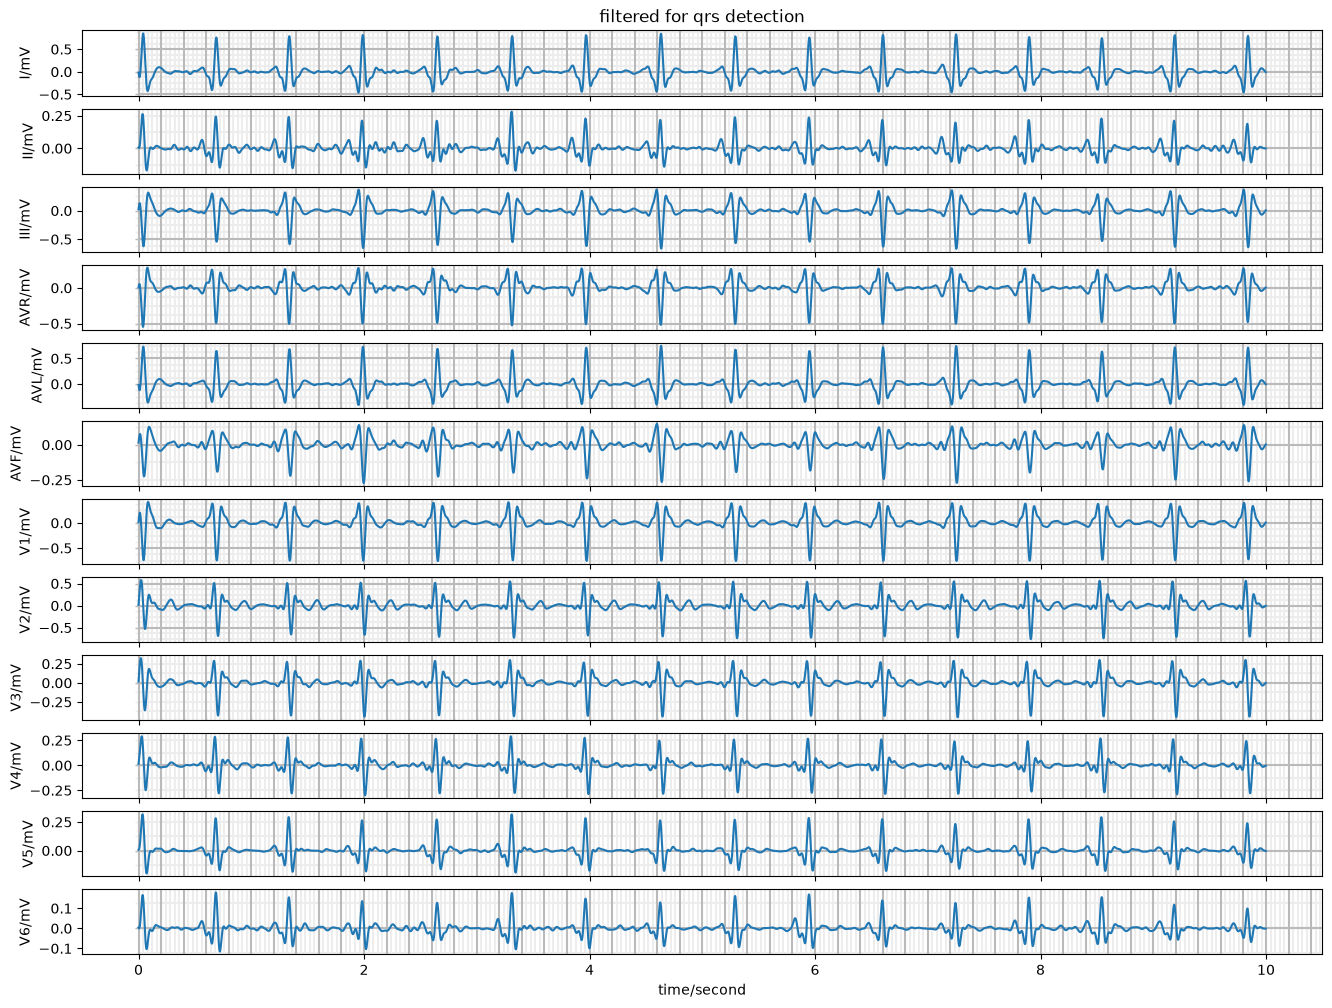

In [8]:
filtered_leads = qrs_detection_bandpass(rec.leads, rec.sample_rate)
rec = rec.model_copy(update={"leads": filtered_leads})
plot_ecg(rec, title="filtered for qrs detection")